# ERCOT Load Forecasting

## 06 — A Genuinely Day-Ahead Protocol

Connecting the model to ERCOT's live API exposed a mismatch. Notebook 05 evaluated a
**rolling** forecast (predict hour *t* using the true load at *t*−24h, which has just been
published). But a realistic day-ahead operation issues **one batch forecast at a fixed
time** for every hour of the next day — and at that moment, most of *today's* load hasn't
happened yet, so `load_24h_ago` is unavailable for most target hours. Likewise, the
`previous_day1` temperature forecast for a late-evening target hour is issued that same
*afternoon* — after our batch would already be out.

**The protocol** (fixed, checkable, leakage-safe):

- **Issuance:** 10:00 AM `America/Chicago` on day *D*.
- **Targets:** all hour-ending timestamps of the next local calendar day *D+1*
  (23, 24, or 25 physical hours, depending on daylight saving time).
- Every feature must be available **before 10:00 AM on day D**.

Availability of each candidate feature at issuance:

| feature | comes from | available by 10 AM on D? |
|---|---|---|
| `hour`, `day_of_week`, `month` | the calendar | yes |
| `load_24h_ago` (hour of D) | ERCOT actuals | **NO — mostly unpublished** |
| `load_48h_ago` (hour of D−1) | ERCOT actuals | yes, if publication delay < 10 h (one live check observed ~1–2 h — an observation, not a guaranteed service level; the live pipeline must re-verify at every issuance) |
| `load_168h_ago` (hour of D−6) | ERCOT actuals | yes, same caveat |
| `previous_day1` temp (issued during D) | GFS | **NO for hours after ~10 AM** |
| `previous_day2` temp (issued during D−1) | GFS | yes, for every target hour |

So the day-ahead feature set replaces `load_24h_ago` → `load_48h_ago` and
`previous_day1` → `previous_day2` temperatures. Two honest notes: this is slightly
*conservative* (a real day-ahead desk would use the day-D morning weather run, fresher
than `previous_day2`, but Open-Meteo's archive only offers whole-day leads), and the
load-publication delay is a runtime assumption the live pipeline must keep checking.

Methodology is otherwise unchanged: chronological split (development 2022–2024, test
2025), TimeSeriesSplit, the same GridSearchCV grids, Gradient Boosting and XGBoost.

In [1]:
import os
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from xgboost import XGBRegressor

## 1. Download the 48-hour-lead temperature forecasts

Same source and model as notebook 05 (Open-Meteo Previous Runs API, pinned
`gfs_global`), but `temperature_2m_previous_day2`: the forecast issued **two days
before** each valid hour — i.e. during day D−1, always before a 10 AM day-D issuance.

In [2]:
cities = {
    "houston": (29.76, -95.36),
    "dallas": (32.78, -96.80),
    "san_antonio": (29.42, -98.49),
    "austin": (30.27, -97.74),
}

forecast_d2_path = "../data/raw/forecast_weather_d2_4cities.csv"

if os.path.exists(forecast_d2_path):
    print("already downloaded, skipping")
else:
    pieces = []
    for city, (lat, lon) in cities.items():
        print(f"{city}: downloading...")
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": "2022-01-01",
            "end_date": "2026-01-01",
            "hourly": "temperature_2m_previous_day2",
            "models": "gfs_global",  #SAME PINNED FORECAST MODEL AS NOTEBOOK 05
            "timezone": "UTC",
        }
        response = requests.get(
            "https://previous-runs-api.open-meteo.com/v1/forecast",
            params=params,
            timeout=120,
        )
        response.raise_for_status()

        df_piece = pd.DataFrame(response.json()["hourly"])
        df_piece["city"] = city
        pieces.append(df_piece)

    forecast_d2_raw = pd.concat(pieces, ignore_index=True)
    forecast_d2_raw.to_csv(forecast_d2_path, index=False)
    print("saved", forecast_d2_path)

houston: downloading...


dallas: downloading...


san_antonio: downloading...


austin: downloading...


saved ../data/raw/forecast_weather_d2_4cities.csv


In [3]:
forecast_d2_raw = pd.read_csv(forecast_d2_path)

print(forecast_d2_raw.shape)
print("missing values:", forecast_d2_raw["temperature_2m_previous_day2"].isna().sum())
print("duplicate (city, time) pairs:",
      forecast_d2_raw.duplicated(subset=["city", "time"]).sum())

(140352, 3)
missing values: 2064
duplicate (city, time) pairs: 0


In [4]:
#PARSE AS UTC FIRST, THEN CONVERT TO TEXAS TIME (SAME AS NOTEBOOKS 02-05)
forecast_d2_raw["time"] = pd.to_datetime(forecast_d2_raw["time"], utc=True)
forecast_d2_raw["time"] = forecast_d2_raw["time"].dt.tz_convert("America/Chicago")

forecast_d2_wide = forecast_d2_raw.pivot(
    index="time",
    columns="city",
    values="temperature_2m_previous_day2",
)
forecast_d2_wide.columns = [f"forecast_temperature_48h_{c}" for c in forecast_d2_wide.columns]

print(forecast_d2_wide.shape)
print("index unique:", forecast_d2_wide.index.is_unique)

(35088, 4)
index unique: True


## 2. Build the 48-hour load lag

`load_48h_ago` is computed from `model_data.csv`, **not** from the forecast dataset:
`model_data.csv` has a complete, continuous hourly load history (one row per hour, no
gaps), so shifting by 48 rows is exactly shifting by 48 physical hours. The forecast
dataset has the ~490-hour archive gap dropped, where a row shift would silently grab
the wrong hours.

In [5]:
load_history = pd.read_csv("../data/processed/model_data.csv", index_col="timestamp")

#MIXED UTC OFFSETS IN THE CSV: PARSE TO UTC FIRST, THEN CONVERT
load_history.index = pd.to_datetime(load_history.index, utc=True).tz_convert("America/Chicago")

# safe to shift by rows only because every consecutive pair is exactly 1 hour apart
hour_steps = load_history.index.to_series().diff().dropna()
assert (hour_steps == pd.Timedelta(hours=1)).all()

load_48h_ago = load_history["ERCOT"].shift(48).rename("load_48h_ago")

print(load_48h_ago.dropna().index.min(), "to", load_48h_ago.index.max())

2022-01-10 01:00:00-06:00 to 2026-01-01 00:00:00-06:00


## 3. Merge and check coverage

Start from `model_data_forecast.csv` (which already holds the calendar features, the
168-hour lag, and — for comparison only — the notebook-05 features), then join the two
new day-ahead columns and drop the few rows where they are missing.

In [6]:
model_df = pd.read_csv("../data/processed/model_data_forecast.csv", index_col="timestamp")
model_df.index = pd.to_datetime(model_df.index, utc=True).tz_convert("America/Chicago")

merged_df = model_df.join(load_48h_ago, how="left")
merged_df = merged_df.join(forecast_d2_wide, how="left")

new_cols = ["load_48h_ago"] + list(forecast_d2_wide.columns)

print("missing new-column values by year:")
print(merged_df[new_cols].isna().groupby(merged_df.index.year).sum())

print("\nmissing in the 2025 test period:",
      merged_df.loc["2025-01-01":, new_cols].isna().sum().sum())

rows_before = len(merged_df)
merged_df = merged_df.dropna(subset=new_cols)
print(f"\ndropped {rows_before - len(merged_df)} of {rows_before} rows "
      f"({(rows_before - len(merged_df)) / rows_before:.1%})")

missing new-column values by year:
           load_48h_ago  forecast_temperature_48h_austin  \
timestamp                                                  
2022                 48                                0   
2023                  0                                0   
2024                  0                               24   
2025                  0                                0   
2026                  0                                0   

           forecast_temperature_48h_dallas  forecast_temperature_48h_houston  \
timestamp                                                                      
2022                                     0                                 0   
2023                                     0                                 0   
2024                                    24                                24   
2025                                     0                                 0   
2026                                     0                      

## 4. Day-ahead feature set and chronological split

In [7]:
#EVERY FEATURE HERE IS AVAILABLE BEFORE 10 AM ON THE DAY BEFORE THE TARGET
features_dayahead = [
    "hour",
    "day_of_week",
    "month",
    "load_48h_ago",
    "load_168h_ago",
    "forecast_temperature_48h_austin",
    "forecast_temperature_48h_dallas",
    "forecast_temperature_48h_houston",
    "forecast_temperature_48h_san_antonio",
]

#SAME CHRONOLOGICAL SPLIT AS NOTEBOOKS 02-05 - NO RANDOM SPLITTING
dev_df = merged_df.loc[:"2024-12-31"]
test_df = merged_df.loc["2025-01-01":]

y_dev = dev_df["ERCOT"]
y_test = test_df["ERCOT"]

tscv = TimeSeriesSplit(n_splits=3)

print("Development:", dev_df.shape)
print("Test:", test_df.shape)

Development: (25571, 39)
Test: (8761, 39)


## 5. Protocol-valid naive baseline

The old naive baseline (predict yesterday's load) is **not allowed** under this
protocol — yesterday hasn't happened at issuance. The honest naive reference is
"predict the same hour two days ago".

In [8]:
y_pred_naive48 = test_df["load_48h_ago"]

naive48_mae = mean_absolute_error(y_test, y_pred_naive48)
naive48_rmse = root_mean_squared_error(y_test, y_pred_naive48)
naive48_r2 = r2_score(y_test, y_pred_naive48)

print("Naive 48h Persistence - Test")
print("MAE:", naive48_mae)
print("RMSE:", naive48_rmse)
print("R2:", naive48_r2)

Naive 48h Persistence - Test
MAE: 3629.728214309782
RMSE: 5099.586166043405
R2: 0.7470716745062898


## 6. Gradient boosting and XGBoost under the day-ahead protocol

Same grids as notebooks 02–05; the only change is the feature set.

In [9]:
#SAME GRID AS NOTEBOOKS 02-05
param_grid_gb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [5, 10, 14],
}

gb_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)
gb_search.fit(dev_df[features_dayahead], y_dev)

y_pred_gb = gb_search.best_estimator_.predict(test_df[features_dayahead])

gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = root_mean_squared_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Best parameters:", gb_search.best_params_)
print("\nGradient Boosting (day-ahead protocol) - Test")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200}

Gradient Boosting (day-ahead protocol) - Test
MAE: 3073.4844886679175
RMSE: 3691.5324728903556
R2: 0.8674618249671613


In [10]:
#SAME GRID AS NOTEBOOKS 02-05
param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=True,
)
xgb_search.fit(dev_df[features_dayahead], y_dev)

y_pred_xgb = xgb_search.best_estimator_.predict(test_df[features_dayahead])

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = root_mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("Best parameters:", xgb_search.best_params_)
print("\nXGBoost (day-ahead protocol) - Test")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

XGBoost (day-ahead protocol) - Test
MAE: 3092.609019046342
RMSE: 3695.693373970777
R2: 0.8671628764744354


## 7. Results — and why they are not directly comparable to notebook 05

Notebook 05's numbers (naive-24h 2518, GB 2211, XGBoost 2218 MW MAE) were measured under
a **rolling protocol**: each hour forecast separately, using information from just 24
hours before. This notebook's numbers are measured under a **stricter batch protocol**:
one 10 AM issuance for all of the next day, using only information available then.
The revised model answers a harder question, so some accuracy loss is expected — the
fair in-protocol reference is the naive 48-hour baseline above.

In [11]:
model_summary = pd.DataFrame({
    "Model": [
        "Naive 48h Persistence (protocol-valid)",
        "Gradient Boosting (day-ahead)",
        "XGBoost (day-ahead)",
    ],
    "MAE": [naive48_mae, gb_mae, xgb_mae],
    "RMSE": [naive48_rmse, gb_rmse, xgb_rmse],
    "R2": [naive48_r2, gb_r2, xgb_r2],
})

model_summary.round(3)

,Model,MAE,RMSE,R2
0,Naive 48h Persistence (protocol-valid),3629.728,5099.586,0.747
1,Gradient Boosting (day-ahead),3073.484,3691.532,0.867
2,XGBoost (day-ahead),3092.609,3695.693,0.867


## 8. Cold-snap check under the stricter protocol

In [12]:
results = pd.DataFrame({
    "actual": y_test,
    "pred_naive48": y_pred_naive48,
    "pred_gb": y_pred_gb,
    "pred_xgb": y_pred_xgb,
})

for case in ["naive48", "gb", "xgb"]:
    results[f"abs_err_{case}"] = (results["actual"] - results[f"pred_{case}"]).abs()

periods = {
    "full test year": results,
    "Jan-Feb 2025": results.loc["2025-01":"2025-02"],
    "2025-01-06 (worst day 1)": results.loc["2025-01-06"],
    "2025-02-19 (worst day 2)": results.loc["2025-02-19"],
}

for name, subset in periods.items():
    print(name)
    print(f"  naive 48h MAE: {subset['abs_err_naive48'].mean():8.1f}")
    print(f"  GB MAE:        {subset['abs_err_gb'].mean():8.1f}")
    print(f"  XGBoost MAE:   {subset['abs_err_xgb'].mean():8.1f}")
    print()

full test year
  naive 48h MAE:   3629.7
  GB MAE:          3073.5
  XGBoost MAE:     3092.6

Jan-Feb 2025
  naive 48h MAE:   5875.6
  GB MAE:          4146.0
  XGBoost MAE:     4075.0

2025-01-06 (worst day 1)
  naive 48h MAE:  16217.1
  GB MAE:          4406.0
  XGBoost MAE:     4176.6

2025-02-19 (worst day 2)
  naive 48h MAE:  18010.4
  GB MAE:         12875.3
  XGBoost MAE:    12656.3



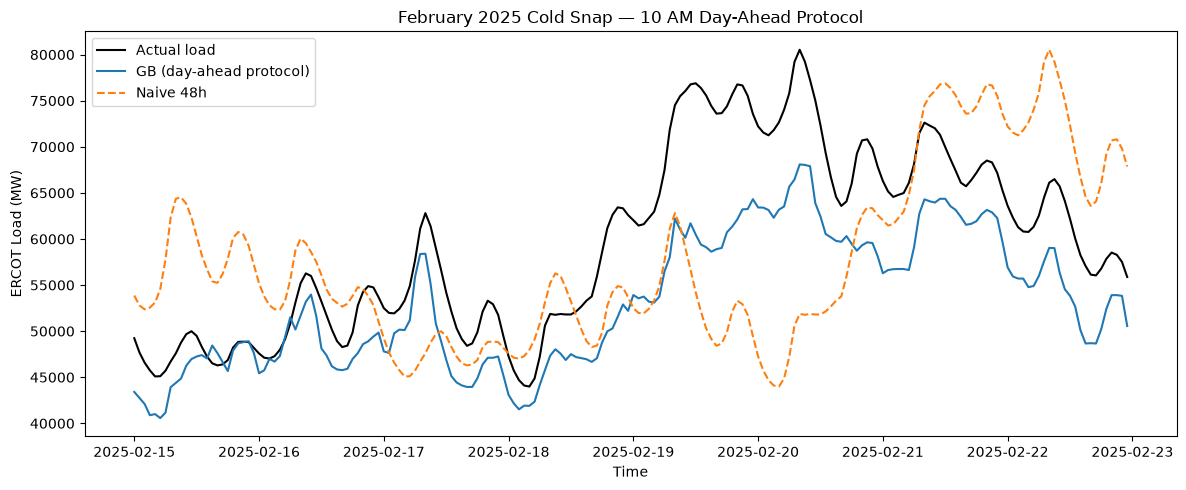

In [13]:
#VISUAL CHECK: THE FEBRUARY 2025 COLD SNAP WEEK
window = results.loc["2025-02-15":"2025-02-22"]

plt.figure(figsize=(12, 5))
plt.plot(window.index, window["actual"], label="Actual load", color="black")
plt.plot(window.index, window["pred_gb"], label="GB (day-ahead protocol)")
plt.plot(window.index, window["pred_naive48"], label="Naive 48h", linestyle="--")

plt.xlabel("Time")
plt.ylabel("ERCOT Load (MW)")
plt.title("February 2025 Cold Snap — 10 AM Day-Ahead Protocol")

plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature importance (best day-ahead model)

load_48h_ago                            0.513356
forecast_temperature_48h_austin         0.244402
forecast_temperature_48h_dallas         0.131778
forecast_temperature_48h_houston        0.026852
hour                                    0.026436
forecast_temperature_48h_san_antonio    0.025292
load_168h_ago                           0.020989
day_of_week                             0.006056
month                                   0.004839
dtype: float64


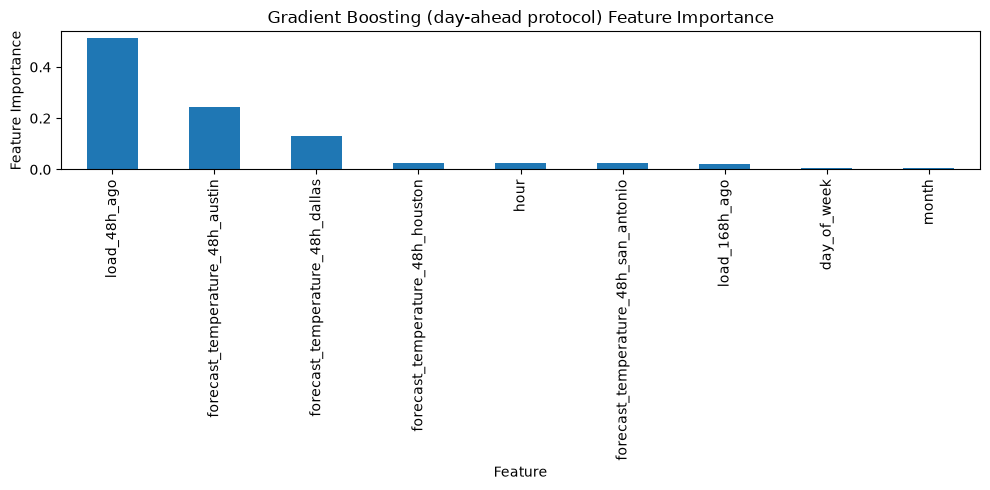

In [14]:
importance = pd.Series(
    gb_search.best_estimator_.feature_importances_,
    index=features_dayahead,
)
importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(10, 5))
importance.plot(kind="bar")

plt.xlabel("Feature")
plt.ylabel("Feature Importance")
plt.title("Gradient Boosting (day-ahead protocol) Feature Importance")

plt.tight_layout()
plt.show()

## 10. Conclusions

**We now have a genuinely day-ahead model — and an honest price tag for it.**

- Under the 10 AM batch protocol, Gradient Boosting reaches **MAE 3073 / RMSE 3692 /
  R² 0.867** (XGBoost essentially tied). Against the protocol-valid naive 48-hour
  baseline (MAE 3630, RMSE 5100) that is a 15% MAE and 28% RMSE improvement.
- Compared to notebook 05's rolling protocol (GB MAE 2211), the batch protocol costs
  about **860 MW of MAE (~39%)**. That is not a modeling regression — it is the measured
  price of using only information available at 10 AM the day before, instead of
  information from 24 hours before each hour.
- **Cold snaps split into two stories.** Jan 6, 2025 is still largely solved: daily MAE
  4406 vs the naive baseline's 16217 — the 48-hour GFS forecast saw that front coming.
  Feb 19, 2025 recovers much less (12875 vs 18010): at 48-hour lead the GFS undershot
  the extreme cold (its error that week: mean ~2 °C, max ~8 °C). Fresher morning-run
  forecasts — which a real desk would have — should close part of that gap, but our
  archive only offers whole-day leads.
- Weather matters **more** under this protocol: the 48-hour temperatures carry ~0.43 of
  the importance (vs ~0.33 in notebook 05), because the staler load lag explains less.

**Where this leaves the project — two valid products, different questions:**

1. The **rolling model** (notebook 05, currently saved and served): forecast hour *t*
   issued ~24 h earlier, MAE ≈ 2211. Valid whenever predictions are made hour-by-hour.
2. The **day-ahead batch model** (this notebook): all of tomorrow at 10 AM, MAE ≈ 3073.
   Valid for a fixed morning issuance schedule.

Neither is wrong; they answer different operational questions and must never be
compared as if they answered the same one. The live pipeline also has one runtime
assumption to keep verifying: yesterday's load must be fully published by 10 AM.
A single live check observed a ~1–2 h publication delay, but one observation is not
a guaranteed latency — every issuance must check availability and refuse to predict
from missing inputs.